In [1]:
# !pip install boruta

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from boruta import BorutaPy
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv('nhanes_all_processed.csv')
feature_types = pd.read_csv('nhanes_var_types.csv')

In [4]:
df.shape

(7587, 128)

In [5]:
# STEP 1: DEFINE TARGET AND ABNORMALITY THRESHOLD

# CHANGE FOR EACH TARGET TEST!!!!
#     target
#     abnormal_threshold
#     abnormal_direction
#     exclusions
#     dropped columns

target = "hdl_cholesterol"
abnormal_direction = "Low" # used for formatting graph titles

# Exclusions
# exclusions
# CHANGE FOR EACH TARGET TEST!!!!
print(f"Number of respondents taking cholesterol medication:{(df["taking_cholesterol_medication"] == 0).sum()}")

df = df[(df['taking_cholesterol_medication'] != 0)]

print(f"New dataframe size {df.shape}")

Number of respondents taking cholesterol medication:1862
New dataframe size (5725, 128)


In [6]:
# drop na targets
print(f"Number of respondents with {target} test:{df[target].notna().sum()}")
df = df.dropna(subset=[target]).reset_index(drop=True)
print(f"New dataframe size {df.shape}")

Number of respondents with hdl_cholesterol test:3969
New dataframe size (3969, 128)


In [7]:
# Create binary target for abnormal vs normal
# CHANGE SIGN FOR EACH TEST!!!
def is_abnormal(row):
    if row['gender'] == 0:  # Male
        return 1 if row[target] < 40 else 0
    else:                   # Female
        return 1 if row[target] < 50 else 0

df[f'{target}_abnormal'] = df.apply(is_abnormal, axis=1)

# Print class distribution for the target variable
print(f"Total samples: {len(df)}")
print(f"Normal {target}: {(df[f'{target}_abnormal'] == 0).sum()} "
      f"({(df[f'{target}_abnormal'] == 0).mean()*100:.1f}%)")
print(f"{abnormal_direction} {target}: {(df[f'{target}_abnormal'] == 1).sum()} "
      f"({(df[f'{target}_abnormal'] == 1).mean()*100:.1f}%)")

Total samples: 3969
Normal hdl_cholesterol: 2982 (75.1%)
Low hdl_cholesterol: 987 (24.9%)


In [8]:
# Columns to drop due to leakage, redundancy or noise:
drop_cols = ["respondent_id", "pregnancy_status_exam",'triglycerides', "hba1c", "vitamin_d","alt", "albumin", "alp", "ast", "bun", "creatine_kinase", "creatinine_serum", "ggt",
             "magnesium", "phosphorus", "potassium", "sodium", "calcium", "total_protein", "uric_acid", "hscrp", "folate",
             "ferritin", "wbc", "hemoglobin", "hematocrit", "cholesterol_total", "triglycerides", "ldl_cholesterol", "hdl_cholesterol",
             "taking_folic_acid", "taking_vitamin_b12", "taking_vitamin_d", "taking_iron", "taking_potassium", "taking_magnesium",
             "taking_calcium", "taking_phosphorus", 'taking_anemia_treatment_past_3mo', 'told_have_liver_condition', 'told_weak_failing_kidneys',
             'exam_season', 'taking_cholesterol_medication', 'told_have_diabetes', 'takes_diabetes_pills', 'freq_use_sunscreen', 'gender']
df_copy = df.drop(columns=drop_cols).copy()
df_copy.shape

(3969, 83)

In [9]:
#STEP 2: DEFINE FEATURE TYPES

cont_features = []
bin_features = []
cat_features = []
ord_features = []


for col in df_copy.columns:
    if col in feature_types["Column Name"].values:
        feat_type = feature_types.loc[feature_types["Column Name"] == col, "Type"].iloc[0]

        if feat_type == "continuous":
            cont_features.append(col)
        elif feat_type == "binary":
            bin_features.append(col)
        elif feat_type == "categorical":
            cat_features.append(col)
        elif feat_type == "ordinal":
            ord_features.append(col)
    else:
        print(f"Warning: {col} not found in feature_types table!")

print(f"Continuous: {len(cont_features)}")
print(f"Ordinal: {len(ord_features)}")
print(f"Binary: {len(bin_features)}")
print(f"Categorical: {len(cat_features)}")

# make sure all features are accounted for (one more in df_copy for the target variable)
print(f"Total Features: {len(cont_features) + len(bin_features) + len(cat_features) + len(ord_features)}")
print(f"Total Columns in df_copy: {len(df_copy.columns)}")

Continuous: 28
Ordinal: 25
Binary: 27
Categorical: 2
Total Features: 82
Total Columns in df_copy: 83


In [10]:
# STEP 3: SPLIT INTO TRAINING AND TEST SETS

X = df_copy.drop(columns=[f"{target}_abnormal"]).copy()
y = df_copy[f"{target}_abnormal"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, # 20% for testing
    random_state=42,
    stratify=y # preserves class balance in both sets
)

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 3175
Testing set size: 794


In [11]:
# STEP 4: PREPROCESSING (one hot encoding, scaling, imputation)

# One hot encoding
# handle_unknown='ignore' is safer for test sets
# sparse_output=False ensures it returns a format we can put back into a DataFrame
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Apply it (This replaces the manual DataFrame joining)
X_train_encoded = ohe.fit_transform(X_train[cat_features])
X_test_encoded = ohe.transform(X_test[cat_features])

# Convert the encoded arrays back into DataFrames
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=ohe.get_feature_names_out(cat_features), index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=ohe.get_feature_names_out(cat_features), index=X_test.index)

# Combine with the numerical/ordinal columns you didn't encode
X_train_pre = pd.concat([X_train.drop(columns=cat_features), X_train_encoded_df], axis=1)
X_test_pre = pd.concat([X_test.drop(columns=cat_features), X_test_encoded_df], axis=1)

In [12]:
# PREPROCESSING (scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pre)
X_test_scaled = scaler.transform(X_test_pre)

In [13]:
# PREPROCESSING (imputation)
imputer = KNNImputer(n_neighbors=5)
X_train_final = imputer.fit_transform(X_train_scaled)
X_test_final = imputer.transform(X_test_scaled)

In [14]:
# Step 5: FEATURE SELECTION (Boruta)

all_features_encoded = X_train_pre.columns.tolist()
print(f"Running Boruta on {len(all_features_encoded)} features....")
# 1. Initialize the "Engine" (Random Forest)
# Boruta works best with a balanced RF use class_weight='balanced'
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=42)

# 2. Initialize Boruta
# n_estimators='auto' lets Boruta decide how many trees it needs
boruta_selector = BorutaPy(rf, n_estimators='auto', random_state=42)

# 3. Fit Boruta
# Boruta needs .values (NumPy array) and cannot handle NaNs
boruta_selector.fit(X_train_final, y_train.values)

# 4. Generate Summary
print("")
print("\033[1m" + "Boruta Feature Selection Summary" + "\033[0m")

selected_features = [f for f, s in zip(all_features_encoded, boruta_selector.support_) if s]
tentative_features = [f for f, s in zip(all_features_encoded, boruta_selector.support_weak_) if s]

print(f"Confirmed Features ({len(selected_features)}): {selected_features}")
print(f"Tentative Features ({len(tentative_features)}): {tentative_features}")

Running Boruta on 90 features....

Boruta Feature Selection Summary
Confirmed Features (13): ['self_rated_health', 'ate_fish_past_30_days', 'age_years', 'income_poverty_ratio', 'food_security_category', 'freq_wear_long_sleeves', 'bmi', 'fat', 'sug_diet', 'caff', 'fiber', 'pulse', 'drinks_per_week']
Tentative Features (0): []


In [15]:
# Create the indices for the 13 features
selected_indices = boruta_selector.support_

# Filter the scaled/imputed NumPy arrays
X_train_selected = X_train_final[:, selected_indices]
X_test_selected = X_test_final[:, selected_indices]

In [16]:
# 7. MODELING (Balanced Random Forest and Logistic Regression)
# Use Boruta-selected features only

# 1. Random Forest
rf = BalancedRandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_selected, y_train)

# 2. Logistic Regression
lr = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    C=0.01,
    l1_ratio=0.5,
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)
lr.fit(X_train_selected, y_train)

# 8. PREDICTIONS & PROBABILITIES

# Probabilities for AUC
rf_train_prob = rf.predict_proba(X_train_selected)[:, 1]
rf_test_prob  = rf.predict_proba(X_test_selected)[:, 1]
lr_train_prob = lr.predict_proba(X_train_selected)[:, 1]
lr_test_prob  = lr.predict_proba(X_test_selected)[:, 1]

# Binary predictions using the threshold
classification_threshold = 0.5
rf_test_pred = (rf_test_prob >= classification_threshold).astype(int)
lr_test_pred = (lr_test_prob >= classification_threshold).astype(int)

RF & LR RESULTS

Random Forest: Train AUC: 0.821 | Test AUC: 0.751 | Gap: 0.070
Logistic Regression: Train AUC: 0.742 | Test AUC: 0.741 | Gap: 0.001

RF Classification Report:
              precision    recall  f1-score   support

      normal       0.88      0.69      0.77       597
         Low       0.43      0.72      0.54       197

    accuracy                           0.70       794
   macro avg       0.66      0.70      0.66       794
weighted avg       0.77      0.70      0.71       794

LR Classification Report:
              precision    recall  f1-score   support

      normal       0.86      0.71      0.78       597
         Low       0.42      0.64      0.51       197

    accuracy                           0.69       794
   macro avg       0.64      0.68      0.64       794
weighted avg       0.75      0.69      0.71       794



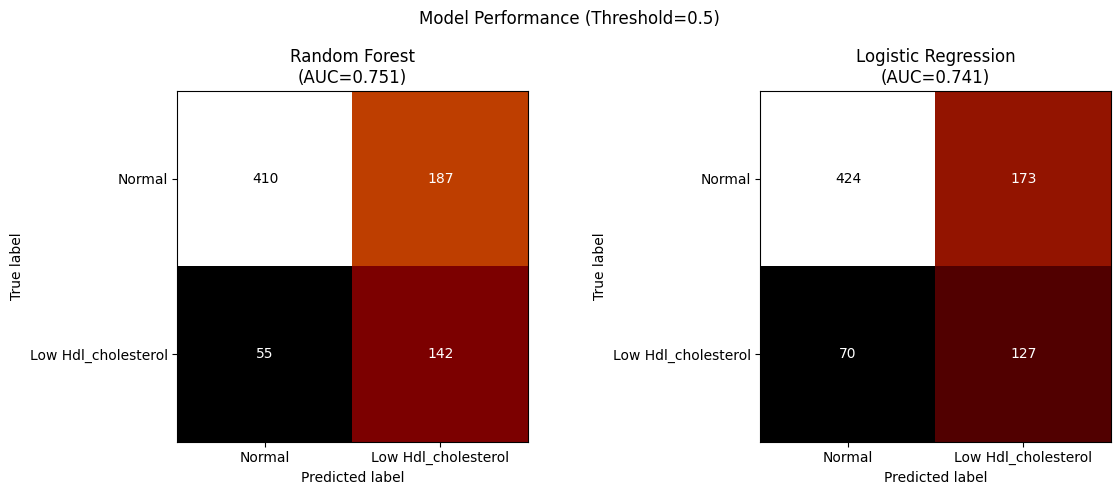

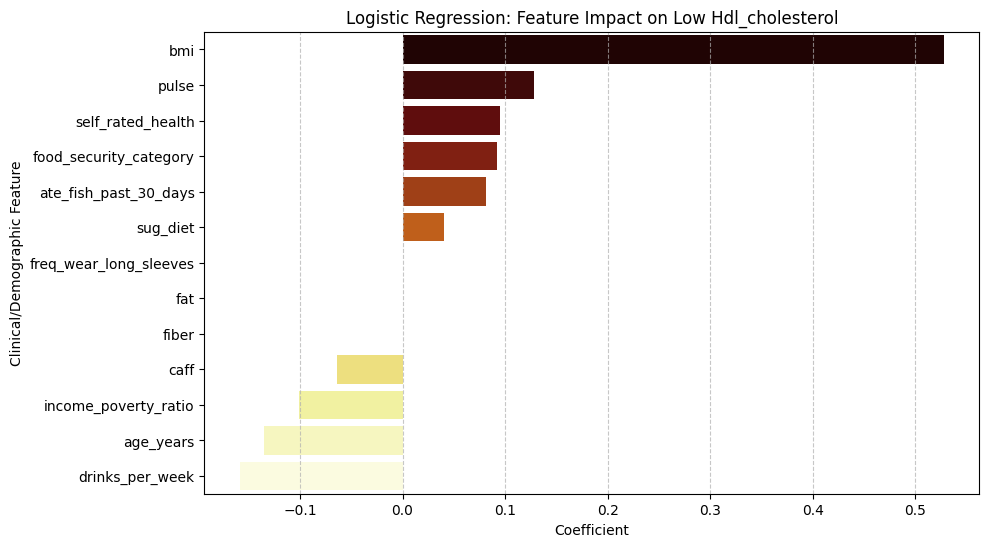

   Clinical/Demographic Feature  Coefficient  Odds Ratio
6                           bmi     0.527976    1.695498
11                        pulse     0.127826    1.136355
0             self_rated_health     0.095113    1.099783
4        food_security_category     0.091677    1.096010
1         ate_fish_past_30_days     0.081610    1.085033
8                      sug_diet     0.040304    1.041127
5        freq_wear_long_sleeves     0.000000    1.000000
7                           fat     0.000000    1.000000
10                        fiber     0.000000    1.000000
9                          caff    -0.063609    0.938372
3          income_poverty_ratio    -0.100493    0.904391
2                     age_years    -0.134734    0.873949
12              drinks_per_week    -0.158977    0.853016


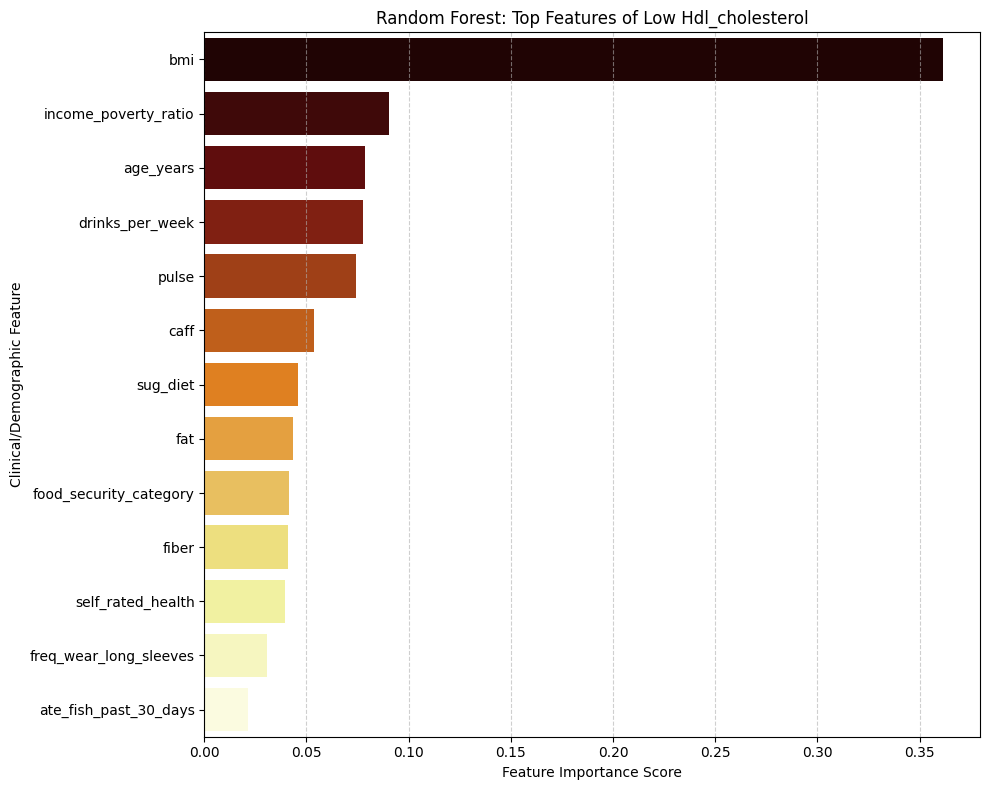

In [17]:
# 9. RESULTS & VISUALIZATION

# Calculate AUCs
rf_train_auc = roc_auc_score(y_train, rf_train_prob)
rf_test_auc  = roc_auc_score(y_test,  rf_test_prob)
lr_train_auc = roc_auc_score(y_train, lr_train_prob)
lr_test_auc  = roc_auc_score(y_test,  lr_test_prob)

print(f"\033[1m" + "RF & LR RESULTS" + "\033[0m")
print("")
print(f"Random Forest: Train AUC: {rf_train_auc:.3f} | Test AUC: {rf_test_auc:.3f} | Gap: {rf_train_auc - rf_test_auc:.3f}")
print(f"Logistic Regression: Train AUC: {lr_train_auc:.3f} | Test AUC: {lr_test_auc:.3f} | Gap: {lr_train_auc - lr_test_auc:.3f}")

print("\nRF Classification Report:")
print(classification_report(y_test, rf_test_pred, target_names=["normal", f"{abnormal_direction}"]))

print("LR Classification Report:")
print(classification_report(y_test, lr_test_pred, target_names=["normal", f"{abnormal_direction}"]))

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# RF Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_test_pred, display_labels=["Normal", f"{abnormal_direction} {target.capitalize()}"], 
    ax=axes[0], cmap='afmhot', colorbar=False
)
axes[0].set_title(f"Random Forest\n(AUC={rf_test_auc:.3f})")

# LR Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_test_pred, display_labels=["Normal", f"{abnormal_direction} {target.capitalize()}"], 
    ax=axes[1], cmap='afmhot', colorbar=False
)
axes[1].set_title(f"Logistic Regression\n(AUC={lr_test_auc:.3f})")

plt.suptitle(f"Model Performance (Threshold={classification_threshold})")
plt.tight_layout()
plt.show()

# Feature Ranking
selected_names = np.array(all_features_encoded)[boruta_selector.support_]
odds_ratio = np.exp(lr.coef_[0])
lr_coefs = pd.DataFrame({
    'Clinical/Demographic Feature': selected_names, # The names of selected features
    'Coefficient': lr.coef_[0],
    "Odds Ratio": odds_ratio
}).sort_values(by='Coefficient', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=lr_coefs, x='Coefficient', y='Clinical/Demographic Feature', palette='afmhot')
plt.title(f"Logistic Regression: Feature Impact on {abnormal_direction} {target.capitalize()}")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print(lr_coefs)

rf_importances = pd.DataFrame({
    'Feature': selected_names,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 3. Plotting
plt.figure(figsize=(10, 8))
sns.barplot(data=rf_importances, x='Importance', y='Feature', palette='afmhot', legend=False)
plt.title(f"Random Forest: Top Features of {abnormal_direction} {target.capitalize()}")
plt.xlabel("Feature Importance Score")
plt.ylabel("Clinical/Demographic Feature")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()